<a href="https://colab.research.google.com/github/yen010390/Heart-Disease-Diagnosis-Model-Comparison-Application/blob/main/Project_3_2_Heart_Disease_Diagnosis_Model_Comparison_Application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **0) Imports / setup**

In [76]:
import os, numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import FunctionTransformer
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif

from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from collections import Counter

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import random


warnings.filterwarnings('ignore')

# Đặt seed để đảm bảo kết quả nhất quán giữa các lần chạy
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(f"Seed: {SEED}")

Seed: 42


# **1) Data loader**


In [4]:
def load_cleveland(file_path="cleveland.csv"):
    UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
    if not os.path.exists(file_path):
        df = pd.read_csv(UCI_URL, header=None, na_values='?')
        df.to_csv(file_path, index=False, header=False)
    df = pd.read_csv(file_path, header=None, na_values='?')
    df.columns = ['age','sex','cp','trestbps','chol','fbs','restecg',
                  'thalach','exang','oldpeak','slope','ca','thal','target']
    # ép kiểu & nhãn nhị phân
    df = df.astype({'ca': float, 'thal': float})
    df['target'] = (df['target'] > 0).astype(int)
    return df

df = load_cleveland()
raw = df.copy()

for c in ["age","trestbps","chol","thalach","oldpeak","ca","thal"]:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

raw["target"] = pd.to_numeric(raw["target"], errors="coerce")
raw["target"] = (raw["target"] > 0).astype(int)
print("Shape:", raw.shape)
display(raw.head())
display(raw.isna().sum())

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# **Visualization**

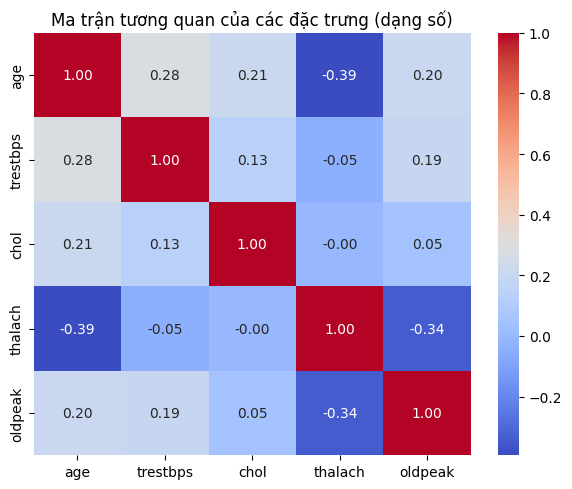

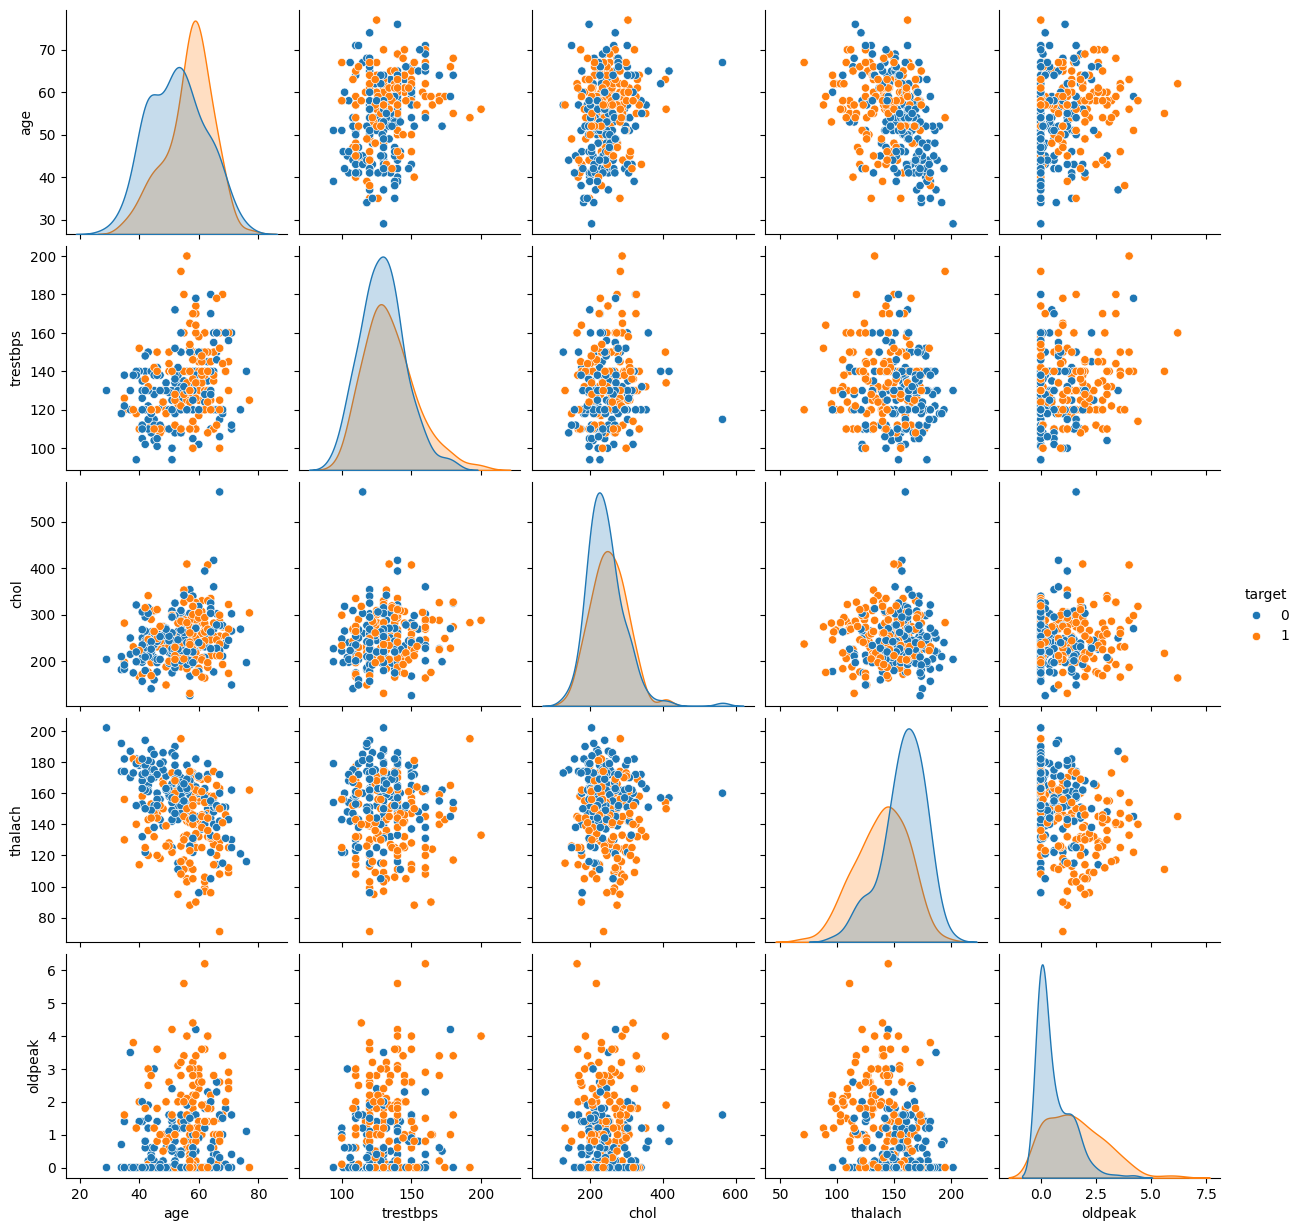

<Figure size 1000x1000 with 0 Axes>

In [6]:
numeric_cols = ["age","trestbps","chol","thalach","oldpeak"]
categorical_cols = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]

plt.figure(figsize=(6, 5))
corr_matrix = raw[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan của các đặc trưng (dạng số)")
plt.tight_layout()
plt.show()

sns.pairplot(raw, vars=numeric_cols, hue="target", diag_kind="kde")
plt.figure(figsize=(10, 10))
plt.suptitle("Phân phối theo từng cặp đặc trưng (dạng số) theo nhãn", y=1.02)
plt.savefig("pairwise_distribution.pdf", bbox_inches="tight")
plt.show()

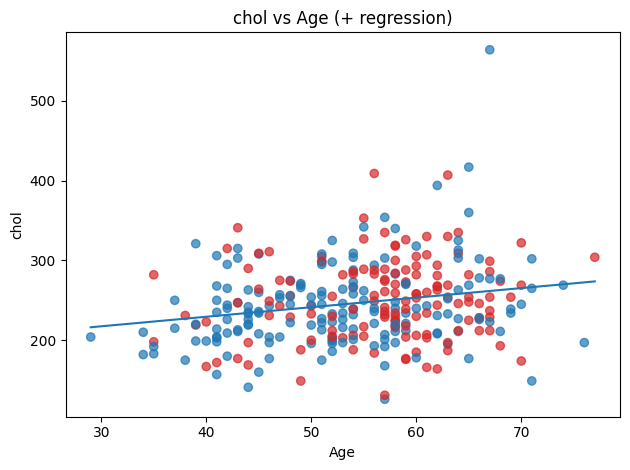

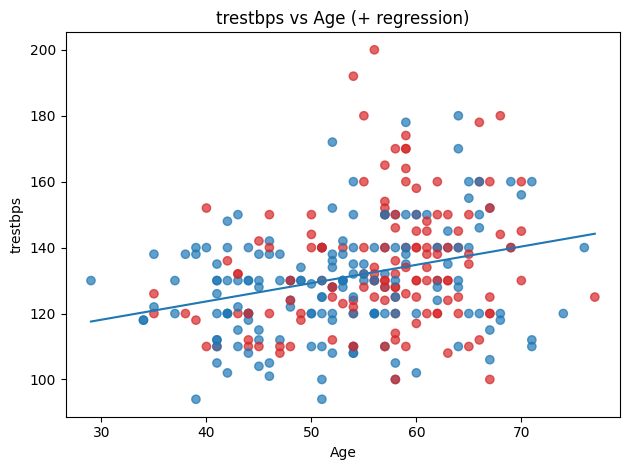

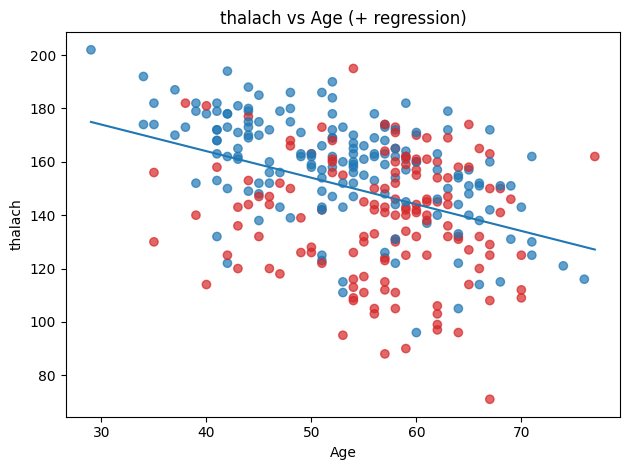

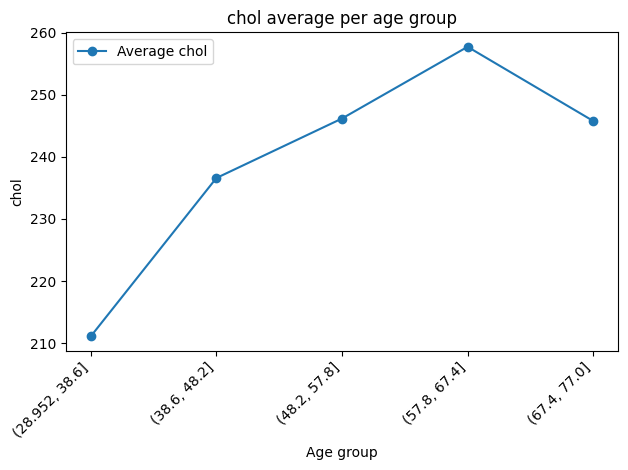

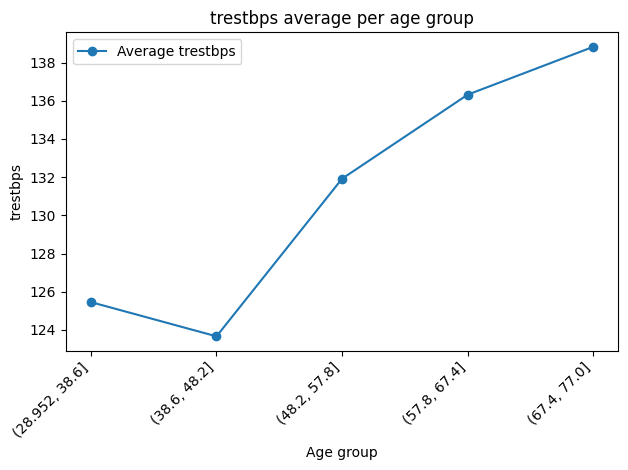

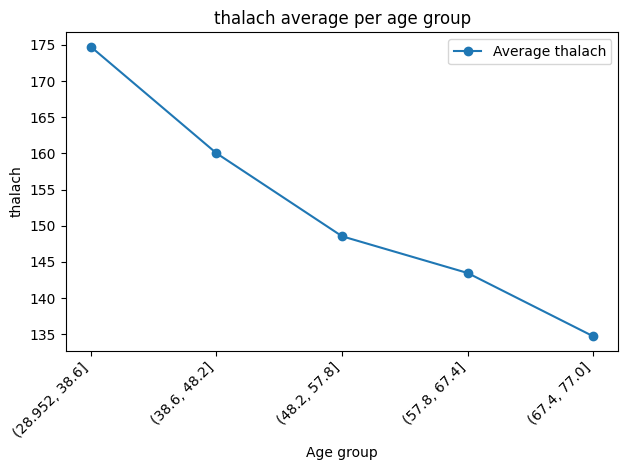

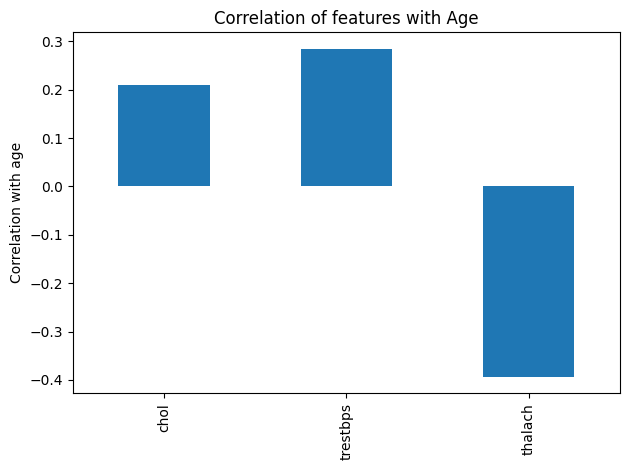

In [7]:
X, y = raw.drop(columns=["target"]), raw["target"]
colors = np.where(y==0, "tab:blue", "tab:red")
metrics = [c for c in ["chol","trestbps","thalach"] if c in X.columns]

def scatter_with_regression(xs, ys, xlab, ylab, title):
  m = xs.notna() & ys.notna()
  x, yy = xs[m].values, ys[m].values
  plt.figure()
  plt.scatter(xs, ys, c=colors, alpha=0.7)
  if len(x) > 1:
    k, b = np.polyfit(x, yy, 1)
    xline = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    plt.plot(xline, k*xline + b)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)
    plt.tight_layout()
    plt.show()

if "age" in X.columns and metrics:
  for col in metrics:
    scatter_with_regression(
        X["age"], X[col],
        "Age", col,
        f"{col} vs Age (+ regression)")

if "age" in X.columns and metrics:
  age_bins = pd.cut(X["age"], bins=5)
  for m in metrics:
    plt.figure()
    avg_vals = X.groupby(age_bins, observed=True)[m].mean()
    plt.plot(range(len(avg_vals)), avg_vals, marker="o", label=f"Average {m}")
    plt.xticks(
        range(len(avg_vals)), map(str, avg_vals.index),
        rotation=45, ha="right"
        )
    plt.xlabel("Age group")
    plt.ylabel(m)
    plt.title(f"{m} average per age group")
    plt.legend()
    plt.tight_layout()
    plt.show()

cols = [c for c in ["age","chol","trestbps","thalach"] if c in X.columns]
if "age" in cols:
  corr = X[cols].corr(numeric_only=True)["age"].drop("age", errors="ignore")
  plt.figure(); corr.plot(kind="bar")
  plt.ylabel("Correlation with age")
  plt.title("Correlation of features with Age")
  plt.tight_layout()
  plt.show()


# **Preprocessing**

In [12]:
TARGET = "target"
feat_cols = raw.columns.drop(TARGET)
X_all, y_all = raw[feat_cols], raw[TARGET]
K = len(feat_cols)

# Tạo các pipeline cho dữ liệu số và dữ liệu phân loại
num_proc = Pipeline([("imp", SimpleImputer(strategy="median")),
                    ("sc", StandardScaler())])
cat_proc = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                    ("sc", MinMaxScaler())])

# Kết hợp các pipeline
preprocess = ColumnTransformer([
    ("num", num_proc, numeric_cols),
     ("cat", cat_proc, categorical_cols),
    ], verbose_feature_names_out=False).set_output(transform="pandas")

raw_pipeline = Pipeline([("preprocess", preprocess)])

# **2) Split train/val/test**

In [18]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

# Chia dữ liệu
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

X_raw_train = raw_pipeline.fit_transform(X_train, y_train)
X_raw_val = raw_pipeline.transform(X_val)
X_raw_test = raw_pipeline.transform(X_test)

# Lưu các tệp đã được xử lý
out_dir = Path("splits"); out_dir.mkdir(parents=True, exist_ok=True)
for name, (X_, y_) in {
    "raw_train": (X_raw_train, y_train),
    "raw_val": (X_raw_val, y_val),
    "raw_test": (X_raw_test, y_test),
    }.items():
    pd.concat(
        [X_, y_.rename(TARGET)], axis=1
        ).to_csv(out_dir / f"{name}.csv", index=False)

print(f"Saved RAW splits. K (RAW features) = {K}")
display(X_raw_train)
display(X_raw_train.isna().sum())

Saved RAW splits. K (RAW features) = 13


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
180,-0.729485,-0.395692,0.458139,0.708371,-0.445445,1.0,1.000000,0.0,1.0,0.0,0.5,0.000000,1.0
208,0.050166,-0.054513,0.230598,0.222495,-0.891627,1.0,0.333333,0.0,0.0,0.0,0.0,0.000000,0.0
167,-0.061212,0.059213,0.723605,0.399178,-0.891627,0.0,0.333333,1.0,1.0,1.0,0.0,0.333333,0.0
105,-0.061212,-1.305501,1.121803,0.266666,-0.891627,1.0,0.333333,0.0,0.0,0.0,0.0,0.000000,1.0
297,0.272924,0.514117,-0.167601,-1.190962,-0.713154,0.0,1.000000,0.0,0.0,1.0,0.5,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.829818,0.514117,2.733557,0.310836,0.179210,0.0,1.000000,0.0,1.0,0.0,0.5,0.000000,0.0
136,1.720848,0.798433,-1.438042,-1.102621,1.428521,1.0,1.000000,0.0,0.0,1.0,1.0,0.000000,1.0
2,1.386712,-0.623144,-0.395142,-0.925938,1.428521,1.0,1.000000,0.0,1.0,1.0,0.5,0.666667,1.0
189,1.609469,0.514117,0.078903,-0.175039,0.893102,1.0,0.666667,0.0,1.0,0.0,0.5,1.000000,1.0


,0
age,0
trestbps,0
chol,0
thalach,0
oldpeak,0
sex,0
cp,0
fbs,0
restecg,0
exang,0


#**Create New Features for FR Dataset**

In [ ]:
# OneHotEncoder: hỗ trợ cả sklearn mới/cũ
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor_fe = ColumnTransformer(
    transformers=[
        # Số: impute -> tạo bậc 2 (bao gồm cả bậc 1) -> scale
        ('num_poly', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('scaler', StandardScaler())
        ]), num_cols),

        # Age binning (one-hot)
        ('age_bins', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('kb', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile'))
        ]), ['age']),

        # Phân loại: impute -> one-hot
        ('cat_ohe', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', ohe)
        ]), cat_cols),
    ],
    verbose_feature_names_out=False
)

model = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)

pipe = Pipeline([
    ('pre', preprocessor_fe),
    ('clf', model)
])

pipe.fit(X_train, y_train)

Saved FE splits. K (FE features) = 13


,fe_topk_features
0,thal_3.0
1,thal_7.0
2,cp_4.0
3,ca_0.0
4,exang_1.0
5,exang_0.0
6,oldpeak
7,slope_1.0
8,chol
9,slope_2.0


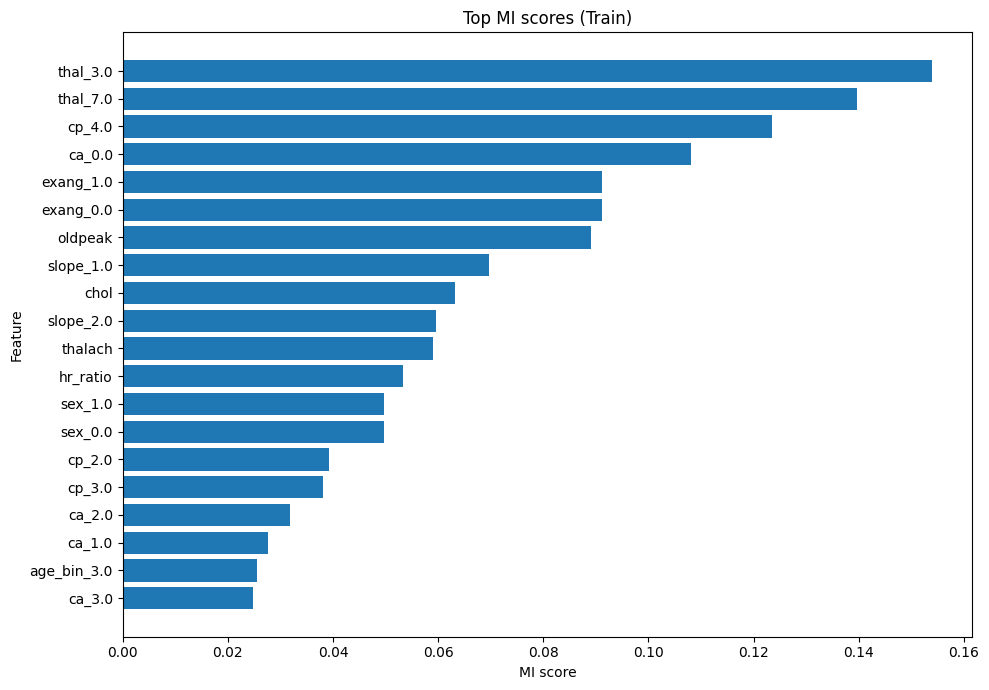

In [24]:
def add_new_features(df):
  df = df.copy()
  if {"chol","age"} <= set(df.columns):
    df["chol_per_age"] = df["chol"]/df["age"]
  if {"trestbps","age"} <= set(df.columns):
    df["bps_per_age"] = df["trestbps"]/df["age"]
  if {"thalach","age"} <= set(df.columns):
    df["hr_ratio"] = df["thalach"]/df["age"]
  if "age" in df.columns:
    df["age_bin"] = pd.cut(df["age"], bins=5, labels=False).astype("category")
  return df

gen_num = ["chol_per_age","bps_per_age","hr_ratio"]
gen_cat = ["age_bin"]
all_nums = [c for c in numeric_cols] + gen_num
all_cats = [c for c in categorical_cols] + gen_cat

num_proc = Pipeline([("imp", SimpleImputer(strategy="median")),
 ("sc", StandardScaler())])
cat_proc = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
 ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

pre = ColumnTransformer([
    ("num", num_proc, all_nums),
     ("cat", cat_proc, all_cats),
    ], verbose_feature_names_out=False).set_output(transform="pandas")

fe_pre = Pipeline([
    ("add", FunctionTransformer(add_new_features, validate=False)),
     ("pre", pre),
    ]).set_output(transform="pandas")

Xt_tr = fe_pre.fit_transform(X_train, y_train)
Xt_va = fe_pre.transform(X_val)
Xt_te = fe_pre.transform(X_test)

nz_cols = Xt_tr.columns[Xt_tr.nunique(dropna=False) > 1]
Xt_tr, Xt_va, Xt_te = Xt_tr[nz_cols], Xt_va[nz_cols], Xt_te[nz_cols]

ohe = fe_pre.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
cat_names = list(ohe.get_feature_names_out(all_cats))
is_discrete = np.array([c in cat_names for c in Xt_tr.columns], dtype=bool)

mi = mutual_info_classif(Xt_tr.values, y_train.values,
discrete_features=is_discrete, random_state=42)
mi_series = pd.Series(mi, index=Xt_tr.columns).sort_values(ascending=False)

K = raw.columns.drop("target").shape[0]
topk_cols = list(mi_series.head(K).index)

fe_tr = Xt_tr[topk_cols].assign(target=y_train.values)
fe_va = Xt_va[topk_cols].assign(target=y_val.values)
fe_te = Xt_te[topk_cols].assign(target=y_test.values)

out = Path("splits"); out.mkdir(parents=True, exist_ok=True)
fe_tr.to_csv(out/"fe_train.csv", index=False)
fe_va.to_csv(out/"fe_val.csv", index=False)
fe_te.to_csv(out/"fe_test.csv", index=False)

print(f"Saved FE splits. K (FE features) = {K}")
display(pd.Series(topk_cols, name="fe_topk_features").reset_index(drop=True))

N = min(20, len(mi_series))
topN = mi_series.head(N).iloc[::-1]
plt.figure(figsize=(10, max(6, 0.35*N)))
plt.barh(topN.index, topN.values)
plt.title("Top MI scores (Train)")
plt.xlabel("MI score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [25]:
!zip -r dataset.zip splits

  adding: splits/ (stored 0%)
  adding: splits/raw_test.csv (deflated 67%)
  adding: splits/fe_train.csv (deflated 74%)
  adding: splits/fe_test.csv (deflated 64%)
  adding: splits/raw_val.csv (deflated 67%)
  adding: splits/raw_train.csv (deflated 81%)
  adding: splits/fe_val.csv (deflated 64%)


9

# **Naive Bayes Classifier**

In [34]:
!gdown 1T6AWCoyeC2MqGvmqZPPcA4ni5Md1k0sI
!unzip dataset.zip

def read_csv(file_path):
  df = pd.read_csv(file_path)
  display(df.head())
  X = df.drop("target", axis=1)
  y = df["target"]

  display(y.value_counts())
  print("Shape df: ", df.shape)
  print("Shape X: ", X.shape)
  print("Shape y: ", y.shape)
  return X, y

Downloading...
From: https://drive.google.com/uc?id=1T6AWCoyeC2MqGvmqZPPcA4ni5Md1k0sI
To: /content/dataset.zip
100% 21.1k/21.1k [00:00<00:00, 62.0MB/s]
Archive:  dataset.zip
replace splits/fe_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: splits/fe_train.csv     
replace splits/raw_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: splits/raw_test.csv     
replace splits/raw_val.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: splits/raw_val.csv      
replace splits/fe_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: splits/fe_test.csv      
replace splits/fe_val.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
  inflating: splits/fe_feature_names.json  
replace splits/raw_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace splits/raw_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: splits/raw_train.csv    


In [37]:
# Tải các bộ dữ liệu gốc đã được xử lý
X_train, y_train = read_csv("splits/raw_train.csv")
X_val, y_val = read_csv("splits/raw_val.csv")
X_test, y_test = read_csv("splits/raw_test.csv")


# Tải các bộ dữ liệu được áp dụng kỹ thuật tạo đặc trưng
X_train_fe, y_train_fe = read_csv("splits/fe_train.csv")
X_val_fe, y_val_fe = read_csv("splits/fe_val.csv")
X_test_fe, y_test_fe = read_csv("splits/fe_test.csv")


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,target
0,-0.729485,-0.395692,0.458139,0.708371,-0.445445,1.0,1.000000,0.0,1.0,0.0,0.5,0.000000,1.0,1
1,0.050166,-0.054513,0.230598,0.222495,-0.891627,1.0,0.333333,0.0,0.0,0.0,0.0,0.000000,0.0,0
2,-0.061212,0.059213,0.723605,0.399178,-0.891627,0.0,0.333333,1.0,1.0,1.0,0.0,0.333333,0.0,0
3,-0.061212,-1.305501,1.121803,0.266666,-0.891627,1.0,0.333333,0.0,0.0,0.0,0.0,0.000000,1.0,0
4,0.272924,0.514117,-0.167601,-1.190962,-0.713154,0.0,1.000000,0.0,0.0,1.0,0.5,0.000000,1.0,1


,count
target,
0,131
1,111


Shape df:  (242, 14)
Shape X:  (242, 13)
Shape y:  (242,)


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,target
0,-1.063621,0.400391,-0.262410,0.089984,-0.713154,0.0,1.000000,0.0,1.0,1.0,0.5,0.0,0.0,0
1,1.720848,-0.054513,1.368307,-1.809349,1.250048,1.0,1.000000,0.0,1.0,0.0,0.5,1.0,0.0,1
2,-0.061212,1.082748,-0.338257,0.664201,0.536156,1.0,0.666667,0.0,1.0,0.0,0.0,0.0,1.0,0
3,0.941197,0.229802,0.040979,0.973394,-0.891627,0.0,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0
4,0.495681,0.229802,-0.300333,0.487519,-0.445445,1.0,1.000000,0.0,0.0,0.0,0.5,0.0,1.0,0


,count
target,
0,16
1,14


...

,count
target,
0,16
1,14


Shape df:  (30, 14)
Shape X:  (30, 13)
Shape y:  (30,)


,thal_3.0,thal_7.0,cp_4.0,ca_0.0,exang_1.0,exang_0.0,oldpeak,slope_1.0,chol,slope_2.0,thalach,hr_ratio,sex_1.0,target
0,0.0,1.0,1.0,0.0,1.0,0.0,1.071575,0.0,-0.641646,1.0,-0.837597,-0.736915,1.0,1
1,1.0,0.0,0.0,1.0,0.0,1.0,-0.891627,1.0,-1.286348,0.0,1.061736,2.749978,1.0,0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.714629,0.0,-0.357219,1.0,-0.175039,-0.619566,1.0,0
3,1.0,0.0,0.0,1.0,0.0,1.0,-0.445445,1.0,0.116827,0.0,-0.042528,0.071622,0.0,0
4,0.0,1.0,0.0,1.0,0.0,1.0,-0.177735,0.0,-0.186562,0.0,1.945146,2.141882,1.0,0


,count
target,
0,17
1,14


Shape df:  (31, 14)
Shape X:  (31, 13)
Shape y:  (31,)


In [38]:
def evaluate_val(X_train, y_train, X_val, y_val):
  # Huấn luyện Naive Bayes
  nbc_model = GaussianNB()
  nbc_model.fit(X_train, y_train)

  # Dự đoán và đánh giá trên tập val
  nb_pred = nbc_model.predict(X_val)
  nb_accuracy = accuracy_score(y_val, nb_pred)

  print(f"Độ chính xác Naive Bayes: {nb_accuracy:.4f}")
  print("\nClassification Report:")
  print(classification_report(y_val, nb_pred))
  return nbc_model, nb_accuracy

def evaluate_test(nbc_model, X_test, y_test):
  # Dự đoán và đánh giá trên tập test
  nb_test_pred = nbc_model.predict(X_test)
  nb_test_accuracy = accuracy_score(y_test, nb_test_pred)

  print(f"Độ chính xác Naive Bayes trên tập test: {nb_test_accuracy:.4f}")
  print("\nClassification Report:")
  print(classification_report(y_test, nb_test_pred))
  return nb_test_accuracy

# Huấn luyện và đánh giá với dữ liệu gốc
model, accuracy = evaluate_val(X_train, y_train, X_val, y_val)
test_accuracy = evaluate_test(model, X_test, y_test)

# Huấn luyện và đánh giá với kỹ thuật tạo đặc trưng
model_fe, accuracy_fe = evaluate_val(X_train_fe, y_train_fe, X_val_fe, y_val_fe)
test_accuracy_fe = evaluate_test(model_fe, X_test_fe, y_test_fe)

Độ chính xác Naive Bayes: 0.9000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.81      0.90        16
           1       0.82      1.00      0.90        14

    accuracy                           0.90        30
   macro avg       0.91      0.91      0.90        30
weighted avg       0.92      0.90      0.90        30

Độ chính xác Naive Bayes trên tập test: 0.8387

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84        17
           1       0.76      0.93      0.84        14

    accuracy                           0.84        31
   macro avg       0.85      0.85      0.84        31
weighted avg       0.85      0.84      0.84        31

Độ chính xác Naive Bayes: 0.9000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.81      0.90        16
           1       0.82      1.00      0.90        1

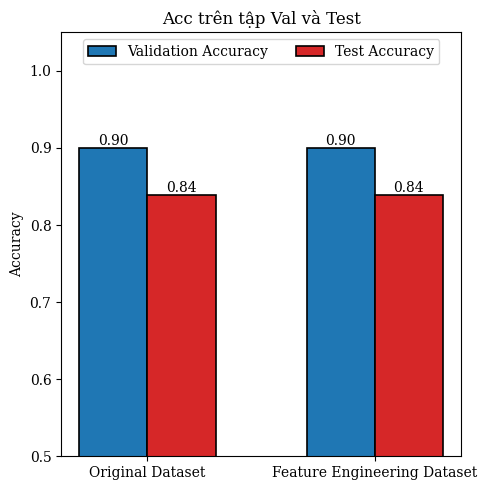

In [40]:
plt.rcParams["font.family"] = "DejaVu Serif"
labels = ["Original Dataset", "Feature Engineering Dataset"]
val_accs = [accuracy, accuracy_fe]
test_accs = [test_accuracy, test_accuracy_fe]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(5, 5))
rects1 = ax.bar(x - width/2, val_accs, width,
                label="Validation Accuracy",
                color="tab:blue", edgecolor="black", linewidth=1.2)
rects2 = ax.bar(x + width/2, test_accs, width,
                label="Test Accuracy",
                color="tab:red", edgecolor="black", linewidth=1.2)

ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Acc trên tập Val và Test")
ax.set_xticks(x)


ax.set_xticklabels(labels)
ax.legend(ncol=2, loc="upper center")

def autolabel(rects):
  for rect in rects:
    h = rect.get_height()
    ax.annotate(f"{h:.2f}", xy=(rect.get_x()+rect.get_width()/2, h),
                ha="center", va="bottom")

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

#**K-Nearest Neighbors**

In [57]:
def find_optimal_k(X_train, y_train, X_val, y_val,
                   k_values=range(1, 21), plot=True):
    k_list = list(k_values)
    scores = []  # <- quan trọng: giữ một LIST các điểm

    for k in k_list:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_val)
        s = accuracy_score(y_val, y_pred)   # hoặc cross_val_score(...).mean()
        scores.append(s)                    # <- append MỖI vòng lặp

    if plot:
        plt.figure()
        plt.plot(k_list, scores, marker="o")
        plt.xlabel("k (n_neighbors)")
        plt.ylabel("accuracy")
        plt.title("Validation accuracy theo k")
        plt.grid(True)
        plt.show()

    # chọn k tốt nhất (nếu có nhiều k cùng điểm, lấy k nhỏ nhất)
    best_k = k_list[int(np.argmax(scores))]
    return best_k


def evaluate_val(X_train, y_train, X_val, y_val, optimal_k):
  # Huấn luyện KNN với k tối ưu
  print(f"Huấn luyện KNN với k tối ưu: {optimal_k}")
  knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
  knn_model.fit(X_train, y_train)

  # Dự đoán và đánh giá trên tập val
  knn_pred = knn_model.predict(X_val)
  knn_accuracy = accuracy_score(y_val, knn_pred)

  print(f"\nĐộ chính xác KNN trên tập validation: {knn_accuracy:.2f}")
  print("Classification Report:")
  print(classification_report(y_val, knn_pred))
  return knn_model, knn_accuracy

def evaluate_test(knn_model, X_test, y_test):
  # Dự đoán và đánh giá trên tập test
  knn_test_pred = knn_model.predict(X_test)
  knn_test_accuracy = accuracy_score(y_test, knn_test_pred)

  print(f"\nĐộ chính xác KNN trên tập test: {knn_test_accuracy:.2f}")
  print("Classification Report:")
  print(classification_report(y_test, knn_test_pred))
  return knn_test_accuracy

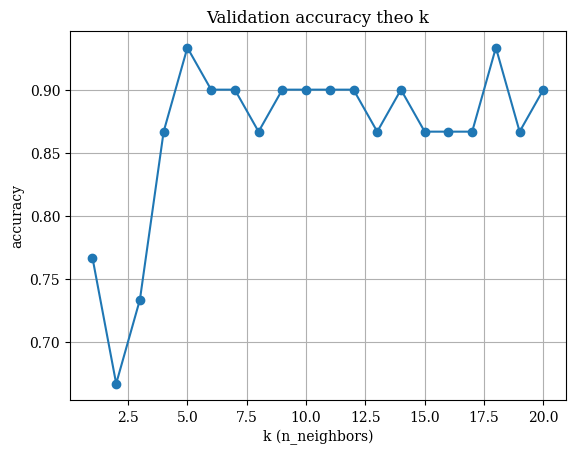

Huấn luyện KNN với k tối ưu: 5

Độ chính xác KNN trên tập validation: 0.93
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93        16
           1       0.88      1.00      0.93        14

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.93        30
weighted avg       0.94      0.93      0.93        30


Độ chính xác KNN trên tập test: 0.84
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86        17
           1       0.85      0.79      0.81        14

    accuracy                           0.84        31
   macro avg       0.84      0.83      0.84        31
weighted avg       0.84      0.84      0.84        31



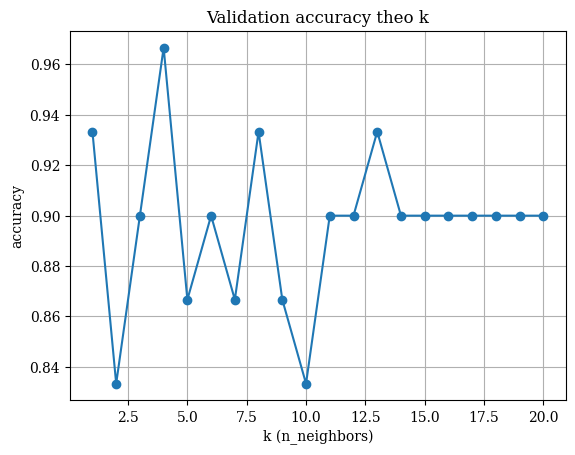

Huấn luyện KNN với k tối ưu: 4

Độ chính xác KNN trên tập validation: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.93      0.96        14

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30


Độ chính xác KNN trên tập test: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        17
           1       0.83      0.71      0.77        14

    accuracy                           0.81        31
   macro avg       0.81      0.80      0.80        31
weighted avg       0.81      0.81      0.80        31



In [58]:
k_optimal = find_optimal_k(X_train, y_train, X_val, y_val)
model, accuracy = evaluate_val(X_train, y_train, X_val, y_val, k_optimal)
test_accuracy = evaluate_test(model, X_test, y_test)

k_optimal = find_optimal_k(X_train_fe, y_train_fe, X_val_fe, y_val_fe)
model_fe, accuracy_fe = evaluate_val(X_train_fe, y_train_fe, X_val_fe, y_val_fe, k_optimal)
test_accuracy_fe = evaluate_test(model_fe, X_test_fe, y_test_fe)

# **Decision Tree**

In [63]:
def find_optimal_depth_val(X_train, y_train, X_val, y_val,
                           depth_range=range(1, 21), min_depth=2, plot=True):
    """
    Chọn độ sâu tối ưu cho Decision Tree dựa trên tập validation.
    """
    depths = list(range(min_depth, depth_range.stop))
    scores = []
    for d in depths:
        dt = DecisionTreeClassifier(max_depth=d, random_state=SEED)
        dt.fit(X_train, y_train)
        scores.append(accuracy_score(y_val, dt.predict(X_val)))

    if plot:
        plt.figure(figsize=(8,5))
        plt.plot(depths, scores, marker="o")
        plt.xlabel("Depth")
        plt.ylabel("Validation accuracy")
        plt.title("Chọn depth tối ưu theo tập validation")
        plt.grid(True)
        plt.show()

    best_d = depths[int(np.argmax(scores))]
    print(f"Depth tối ưu (VAL): {best_d}")
    return best_d


def evaluate_val(X_train, y_train, X_val, y_val, optimal_depth):
    # Huấn luyện với độ sâu tối ưu
    dt_model = DecisionTreeClassifier(max_depth=optimal_depth, random_state=SEED)
    dt_model.fit(X_train, y_train)

    # Dự đoán và đánh giá trên tập val
    dt_pred = dt_model.predict(X_val)
    dt_accuracy = accuracy_score(y_val, dt_pred)
    print(f"\nĐộ chính xác Decision Tree trên tập validation: {dt_accuracy:.2f}")
    print("Classification Report:")
    print(classification_report(y_val, dt_pred))
    return dt_model, dt_accuracy


def evaluate_test(dt_model, X_test, y_test):
    # Dự đoán và đánh giá trên tập test
    dt_test_pred = dt_model.predict(X_test)
    dt_test_accuracy = accuracy_score(y_test, dt_test_pred)
    print(f"\nĐộ chính xác Decision Tree trên tập test: {dt_test_accuracy:.2f}")
    print("Classification Report:")
    print(classification_report(y_test, dt_test_pred))
    return dt_test_accuracy


def display_feature_importance(dt_model, X_train):
    # Hiển thị các đặc trưng có ảnh hưởng lớn
    feature_importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": dt_model.feature_importances_
    }).sort_values("importance", ascending=False)
    print("\nXếp hạng Features quan trọng:")
    display(feature_importance.head(10))

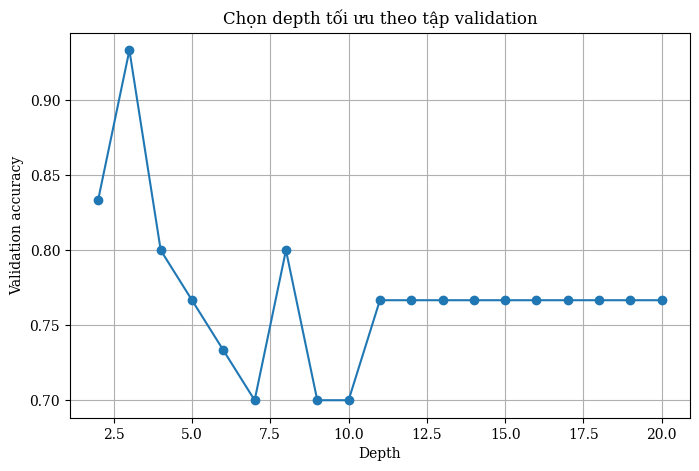

Depth tối ưu (VAL): 3

Độ chính xác Decision Tree trên tập validation: 0.93
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.93      0.93      0.93        14

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Độ chính xác Decision Tree trên tập test: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        17
           1       0.79      0.79      0.79        14

    accuracy                           0.81        31
   macro avg       0.80      0.80      0.80        31
weighted avg       0.81      0.81      0.81        31


Xếp hạng Features quan trọng:


,feature,importance
12,thal,0.536927
6,cp,0.194140
11,ca,0.168773
4,oldpeak,0.066853
0,age,0.033307
3,thalach,0.000000
2,chol,0.000000
1,trestbps,0.000000
5,sex,0.000000
8,restecg,0.000000


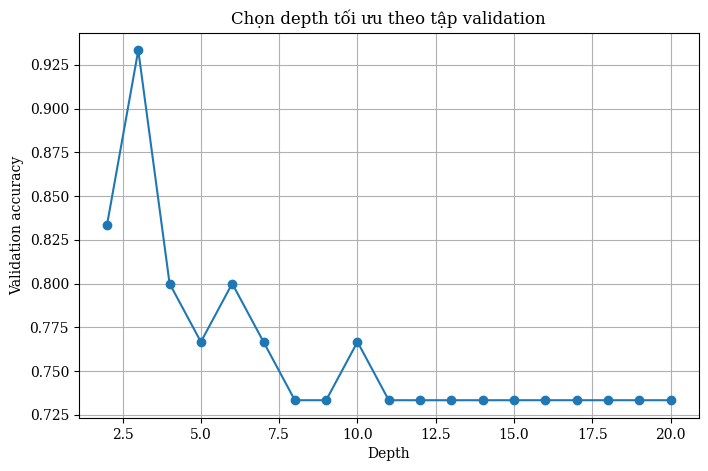

Depth tối ưu (VAL): 3

Độ chính xác Decision Tree trên tập validation: 0.93
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.93      0.93      0.93        14

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Độ chính xác Decision Tree trên tập test: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        17
           1       0.79      0.79      0.79        14

    accuracy                           0.81        31
   macro avg       0.80      0.80      0.80        31
weighted avg       0.81      0.81      0.81        31


Xếp hạng Features quan trọng:


,feature,importance
0,thal_3.0,0.535670
2,cp_4.0,0.193685
3,ca_0.0,0.168378
6,oldpeak,0.066697
11,hr_ratio,0.035570
4,exang_1.0,0.000000
1,thal_7.0,0.000000
7,slope_1.0,0.000000
5,exang_0.0,0.000000
8,chol,0.000000


In [64]:
depth_optimal = find_optimal_depth_val(X_train, y_train, X_val, y_val)
model, accuracy = evaluate_val(X_train, y_train, X_val, y_val, depth_optimal)
test_accuracy = evaluate_test(model, X_test, y_test)
display_feature_importance(model, X_train)

depth_optimal = find_optimal_depth_val(X_train_fe, y_train_fe, X_val_fe, y_val_fe)
model_fe, accuracy_fe = evaluate_val(X_train_fe, y_train_fe, X_val_fe, y_val_fe, depth_optimal)
test_accuracy_fe = evaluate_test(model_fe, X_test_fe, y_test_fe)
display_feature_importance(model_fe, X_train_fe)

# **K-means**

In [65]:
def _build_cluster_class_mapping(labels_train: np.ndarray, y_train: np.ndarray) -> dict:
    """
    Tạo mapping: cluster_id -> class (đa số) dựa trên nhãn thật của tập train.
    """
    mapping = {}
    for cid in np.unique(labels_train):
        mask = (labels_train == cid)
        # Tránh trường hợp cluster rỗng (hiếm): gán tạm bằng mode toàn cục
        if not np.any(mask):
            majority = Counter(y_train).most_common(1)[0][0]
        else:
            majority = Counter(y_train[mask]).most_common(1)[0][0]
        mapping[cid] = majority
    return mapping


def evaluate_val(X_train, y_train, X_val, y_val, n_clusters=2, random_state=42, init="random"):
    # Huấn luyện KMeans
    kmean_model = KMeans(n_clusters=n_clusters, random_state=random_state, init=init)
    kmean_model.fit(X_train)

    # Tạo mapping cluster -> class từ tập train
    train_clusters = kmean_model.labels_
    cluster_class_mapping = _build_cluster_class_mapping(train_clusters, np.asarray(y_train))

    # Lưu mapping vào model để dùng lại ở test
    kmean_model.cluster_class_mapping_ = cluster_class_mapping

    # Dự đoán và đánh giá trên tập validation
    val_clusters = kmean_model.predict(X_val)
    kmeans_pred = np.array([cluster_class_mapping[cid] for cid in val_clusters])
    kmeans_accuracy = accuracy_score(y_val, kmeans_pred)

    print(f"Độ chính xác KMeans (Binary/Multiclass Prediction): {kmeans_accuracy:.4f}")
    print("\nClassification Report (KMeans Prediction):")
    print(classification_report(y_val, kmeans_pred))

    return kmean_model, kmeans_accuracy


def evaluate_test(kmean_model, X_test, y_test):
    # Kiểm tra đã có mapping từ bước validation
    if not hasattr(kmean_model, "cluster_class_mapping_"):
        raise AttributeError(
            "Model chưa có 'cluster_class_mapping_'. Hãy gọi evaluate_val trước, "
            "hoặc tự gắn thuộc tính này cho model."
        )

    # Dự đoán trên tập test
    test_clusters = kmean_model.predict(X_test)
    mapping = kmean_model.cluster_class_mapping_
    kmeans_test_pred = np.array([mapping[cid] for cid in test_clusters])

    # Đánh giá
    kmeans_test_accuracy = accuracy_score(y_test, kmeans_test_pred)
    print(f"Độ chính xác KMeans trên tập test: {kmeans_test_accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, kmeans_test_pred))

    return kmeans_test_accuracy


In [70]:
model, accuracy = evaluate_val(X_train, y_train, X_val, y_val)
test_accuracy = evaluate_test(model, X_test, y_test)

model_fe, accuracy_fe = evaluate_val(X_train_fe, y_train_fe, X_val_fe, y_val_fe)
test_accuracy_fe = evaluate_test(model_fe, X_test_fe, y_test_fe)

Độ chính xác KMeans (Binary/Multiclass Prediction): 0.7000

Classification Report (KMeans Prediction):
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        16
           1       0.69      0.64      0.67        14

    accuracy                           0.70        30
   macro avg       0.70      0.70      0.70        30
weighted avg       0.70      0.70      0.70        30

Độ chính xác KMeans trên tập test: 0.8710

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        17
           1       0.81      0.93      0.87        14

    accuracy                           0.87        31
   macro avg       0.87      0.88      0.87        31
weighted avg       0.88      0.87      0.87        31

Độ chính xác KMeans (Binary/Multiclass Prediction): 0.8000

Classification Report (KMeans Prediction):
              precision    recall  f1-score   support

           0       

# **Triển khai**

In [71]:
def evaluate_val(X_train, y_train, X_val, y_val, n_clusters=2):
    """
    Huấn luyện KMeans trên tập train, ánh xạ cluster -> class theo đa số,
    đánh giá trên tập validation và lưu mapping vào model để dùng lại cho test.
    """
    # Huấn luyện
    kmean_model = KMeans(n_clusters=n_clusters, random_state=SEED, init="random")
    kmean_model.fit(X_train)

    # Dự đoán và đánh giá trên tập val
    val_clusters = kmean_model.predict(X_val)
    train_clusters = kmean_model.labels_

    # Tạo mapping: cluster_id -> class (đa số) dựa vào y_train
    cluster_class_mapping = {
        cluster_id: Counter(np.asarray(y_train)[train_clusters == cluster_id]).most_common(1)[0][0]
        for cluster_id in np.unique(train_clusters)
    }

    # Lưu mapping vào model để dùng lại ở bước test
    kmean_model.cluster_class_mapping_ = cluster_class_mapping

    # Biến cluster dự đoán thành class dự đoán
    kmeans_pred = np.array([cluster_class_mapping[cluster_id] for cluster_id in val_clusters])
    kmeans_accuracy = accuracy_score(y_val, kmeans_pred)

    print(f"Độ chính xác KMeans (Binary/Multiclass Prediction): {kmeans_accuracy:.4f}")
    print("\nClassification Report (KMeans Prediction):")
    print(classification_report(y_val, kmeans_pred))

    return kmean_model, kmeans_accuracy


def evaluate_test(kmean_model, X_test, y_test):
    """
    Dùng model KMeans đã có 'cluster_class_mapping_' để dự đoán và đánh giá trên test.
    """
    if not hasattr(kmean_model, "cluster_class_mapping_"):
        raise AttributeError(
            "Model chưa có 'cluster_class_mapping_'. Hãy gọi evaluate_val trước, "
            "hoặc tự gắn thuộc tính này cho model."
        )

    # Dự đoán trên tập test
    test_clusters = kmean_model.predict(X_test)
    cluster_class_mapping = kmean_model.cluster_class_mapping_

    # Biến cluster dự đoán thành class dự đoán
    kmeans_test_pred = np.array([cluster_class_mapping[cluster_id] for cluster_id in test_clusters])
    kmeans_test_accuracy = accuracy_score(y_test, kmeans_test_pred)

    print(f"Độ chính xác KMeans trên tập test: {kmeans_test_accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, kmeans_test_pred))

    return kmeans_test_accuracy

In [72]:
model, accuracy = evaluate_val(X_train, y_train, X_val, y_val)
test_accuracy = evaluate_test(model, X_test, y_test)

model_fe, accuracy_fe = evaluate_val(X_train_fe, y_train_fe, X_val_fe, y_val_fe)
test_accuracy_fe = evaluate_test(model_fe, X_test_fe, y_test_fe)

Độ chính xác KMeans (Binary/Multiclass Prediction): 0.7000

Classification Report (KMeans Prediction):
              precision    recall  f1-score   support

           0       0.71      0.75      0.73        16
           1       0.69      0.64      0.67        14

    accuracy                           0.70        30
   macro avg       0.70      0.70      0.70        30
weighted avg       0.70      0.70      0.70        30

Độ chính xác KMeans trên tập test: 0.8710

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        17
           1       0.81      0.93      0.87        14

    accuracy                           0.87        31
   macro avg       0.87      0.88      0.87        31
weighted avg       0.88      0.87      0.87        31

Độ chính xác KMeans (Binary/Multiclass Prediction): 0.8000

Classification Report (KMeans Prediction):
              precision    recall  f1-score   support

           0       

In [73]:
def init_model():
  # Khởi tạo mô hình Stacking Ensemble
  ensemble_model = StackingClassifier(
      estimators=[
          ("knn", KNeighborsClassifier()),
           ("dt", DecisionTreeClassifier(random_state=SEED)),
            ("nb", GaussianNB()),
          ],
      final_estimator=KNeighborsClassifier(),
      stack_method="predict_proba",
      passthrough=False
      )
  display(ensemble_model)
  return ensemble_model

In [74]:
def evaluate_ensemble(ensemble_model, X_train, y_train, X_val, y_val):
  ensemble_model.fit(X_train, y_train)
  ensemble_pred = ensemble_model.predict(X_val)
  ensemble_accuracy = accuracy_score(y_val, ensemble_pred)
  print(f"Độ chính xác Ensemble Model: {ensemble_accuracy:.4f}")
  print("\nClassification Report:")
  print(classification_report(y_val, ensemble_pred))
  return ensemble_accuracy

def evaluate_ensemble_test(ensemble_model, X_test, y_test):
  ensemble_test_pred = ensemble_model.predict(X_test)
  ensemble_test_accuracy = accuracy_score(y_test, ensemble_test_pred)
  print(f"Độ chính xác Ensemble trên tập test: {ensemble_test_accuracy:.4f}")
  print("\nClassification Report:")
  print(classification_report(y_test, ensemble_test_pred))
  return ensemble_test_accuracy

In [77]:
ensemble_model = init_model()
accuracy = evaluate_ensemble(
    ensemble_model,
    X_train,
    y_train,
    X_val,
    y_val
    )
test_accuracy = evaluate_ensemble_test(
    ensemble_model,
    X_test,
    y_test)

StackingClassifier(estimators=[('knn', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('nb', GaussianNB())],
                   final_estimator=KNeighborsClassifier(),
                   stack_method='predict_proba')

Độ chính xác Ensemble Model: 0.8667

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        16
           1       0.86      0.86      0.86        14

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30

Độ chính xác Ensemble trên tập test: 0.8387

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84        17
           1       0.76      0.93      0.84        14

    accuracy                           0.84        31
   macro avg       0.85      0.85      0.84        31
weighted avg       0.85      0.84      0.84        31



In [78]:
ensemble_model_fe = init_model()
accuracy_fe = evaluate_ensemble(
    ensemble_model_fe,
    X_train_fe,
    y_train_fe,
    X_val_fe,
    y_val_fe
    )

test_accuracy_fe = evaluate_ensemble_test(
    ensemble_model_fe,
    X_test_fe,
    y_test_fe
    )

StackingClassifier(estimators=[('knn', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('nb', GaussianNB())],
                   final_estimator=KNeighborsClassifier(),
                   stack_method='predict_proba')

Độ chính xác Ensemble Model: 0.9333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93        16
           1       0.88      1.00      0.93        14

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.93        30
weighted avg       0.94      0.93      0.93        30

Độ chính xác Ensemble trên tập test: 0.9032

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        17
           1       0.82      1.00      0.90        14

    accuracy                           0.90        31
   macro avg       0.91      0.91      0.90        31
weighted avg       0.92      0.90      0.90        31

